# Explore here

# Proyecto Final 
Integrantes: 
- Luis Guillermo Perez
- Daniel Delgado
- Alejandro Zuloaga

In [1]:
# Your code here
import os
import json

# Tus datos de acceso
kaggle_data = {
    "username": "alezuloaga",
    "key": "KGAT_f15f24f3508f75c0f573d1ccc699b0de"
}

# Creamos la carpeta .kaggle y el archivo json
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_data, f)

# Asignamos permisos de lectura (importante en sistemas basados en Linux/Mac)
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

In [2]:
# Instalar la librería si es necesario
# !pip install kaggle

import kaggle

# Descargar el dataset usando el identificador del link
dataset_id = "sergionefedov/fraud-detection-1m-transactions-7-fraud-types"

print("Descargando dataset...")
kaggle.api.dataset_download_files(dataset_id, path='../data/raw', unzip=True)
print("¡Listo! El archivo .csv ya debería aparecer en tu carpeta actual.")

Descargando dataset...
Dataset URL: https://www.kaggle.com/datasets/sergionefedov/fraud-detection-1m-transactions-7-fraud-types
¡Listo! El archivo .csv ya debería aparecer en tu carpeta actual.


In [3]:
import pandas as pd 

df_account_profiles = pd.read_csv('../data/raw/account_profiles.csv')
df_fraud_patterns = pd.read_csv('../data/raw/fraud_patterns.csv')
df_transactions = pd.read_csv('../data/raw/transactions.csv')

# Revisión de datos

In [4]:
df_account_profiles

,account_id,account_age_days,credit_limit,home_country,risk_score,is_high_risk,avg_txn_amount,avg_monthly_txns,has_2fa,account_type,...,max_amount,fraud_count,fraud_amount,pct_foreign,avg_velocity,unique_countries,unique_categories,avg_ip_risk,fraud_rate,is_fraudster
0,ACC0000001,353,2171.42,US,16.5,0,90.82,71.1,1,personal,...,740.46,0.0,0.00,0.35,1.27,9.0,11.0,22.98,0.0,0.0
1,ACC0000002,2831,3031.38,US,25.4,0,63.78,7.4,1,business,...,186.13,1.0,186.13,0.50,4.00,2.0,2.0,52.45,0.5,1.0
2,ACC0000003,2399,7533.75,US,10.6,0,72.18,31.9,0,personal,...,1175.86,0.0,0.00,0.17,1.44,3.0,8.0,15.50,0.0,0.0
3,ACC0000004,1618,4821.94,US,20.7,0,53.64,16.6,1,personal,...,2753.31,0.0,0.00,0.33,1.11,4.0,10.0,19.01,0.0,0.0
4,ACC0000005,1597,3355.10,US,30.6,0,168.44,32.0,1,personal,...,718.61,0.0,0.00,0.42,0.95,7.0,12.0,26.71,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,ACC0049996,2038,1010.45,US,11.7,0,40.87,11.8,0,premium,...,256.12,0.0,0.00,0.29,1.43,3.0,6.0,22.20,0.0,0.0
49996,ACC0049997,3612,21009.65,US,14.4,0,151.02,16.2,1,personal,...,480.34,0.0,0.00,0.18,1.09,3.0,8.0,16.15,0.0,0.0
49997,ACC0049998,611,4207.53,US,40.6,0,93.20,6.1,1,personal,...,65.56,0.0,0.00,0.67,1.33,3.0,3.0,28.63,0.0,0.0
49998,ACC0049999,1152,2464.17,US,4.3,0,164.56,13.5,1,personal,...,550.99,0.0,0.00,0.00,0.85,1.0,7.0,12.80,0.0,0.0


In [5]:
df_fraud_patterns

,fraud_pattern,description,transaction_count,fraud_share_pct,avg_amount,median_amount,pct_night_0_5,pct_foreign,pct_card_not_present,avg_velocity_1h,avg_ip_risk,pct_no_2fa
0,card_not_present,Online/CNP fraud — stolen card details used wi...,5982,34.89,771.78,268.63,41.32,58.06,73.12,3.98,55.26,42.24
1,account_takeover,Fraudster gains access to legitimate account v...,3432,20.02,1203.13,436.78,40.88,59.64,74.24,3.96,55.89,41.72
2,card_present_stolen,Physical card stolen and used at POS terminals,3120,18.20,556.84,200.27,40.83,57.24,73.17,3.95,54.99,40.61
3,friendly_fraud,Legitimate cardholder disputes valid transacti...,1726,10.07,352.61,120.80,38.99,55.97,74.68,3.93,54.91,42.47
4,atm_fraud,ATM skimming or card trapping to clone card,1216,7.09,466.26,164.53,40.87,60.44,76.23,4.04,55.60,39.39
5,money_laundering,Series of transactions to disguise illicit fun...,1011,5.90,93.59,35.42,40.36,60.63,72.21,3.97,55.79,44.02
6,identity_theft,New account opened using stolen personal infor...,656,3.83,1163.50,387.26,38.72,57.62,75.30,3.93,55.14,42.23


In [6]:
df_transactions

,transaction_id,account_id,timestamp,hour_of_day,day_of_week,is_weekend,amount,merchant_category,mcc_code,merchant_country,...,ip_risk_score,is_foreign_txn,time_since_last_s,velocity_1h,amount_vs_avg_ratio,account_age_days,has_2fa,credit_limit,is_fraud,fraud_pattern
0,TXN000000001,ACC0016173,2023-02-21 08:02:38,8,1,0,168.42,travel,4511,CA,...,53.2,1,21,3,2.6423,3256,1,3958.46,0,NaN
1,TXN000000002,ACC0011196,2024-05-12 23:13:34,23,6,1,85.78,online_retail,5999,AU,...,25.3,1,234,1,0.7279,1527,1,3553.35,0,NaN
2,TXN000000003,ACC0001181,2023-09-22 23:28:21,23,4,0,20.15,pharmacy,5912,CA,...,21.3,1,85,1,0.1851,2230,1,4362.57,0,NaN
3,TXN000000004,ACC0037105,2022-09-28 23:26:38,23,2,0,62.49,grocery,5411,US,...,13.7,0,98,0,1.5223,1863,1,3194.84,0,NaN
4,TXN000000005,ACC0028471,2023-02-23 17:54:13,17,3,0,71.68,online_retail,5999,US,...,9.7,0,721,2,0.7724,1728,0,11850.06,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,TXN000999996,ACC0003383,2022-06-22 06:22:38,6,2,0,63.66,restaurant,5812,US,...,15.2,0,266,0,1.7937,3508,1,2176.89,0,NaN
999996,TXN000999997,ACC0047607,2022-07-31 18:24:02,18,6,1,148.62,online_retail,5999,US,...,6.3,0,249,1,6.5013,3070,1,6167.60,0,NaN
999997,TXN000999998,ACC0017496,2022-06-21 15:47:50,15,1,0,55.08,grocery,5411,US,...,22.0,0,28,0,0.9797,3130,0,2632.33,0,NaN
999998,TXN000999999,ACC0008364,2022-01-06 22:12:19,22,3,0,29.13,grocery,5411,US,...,6.5,0,167,0,0.2111,491,0,7975.95,0,NaN


In [7]:

# 1. limpieza de nombres de columnas (quitar espacios en blanco)
df_transactions.columns = df_transactions.columns.str.strip()
df_account_profiles.columns = df_account_profiles.columns.str.strip()
df_fraud_patterns.columns = df_fraud_patterns.columns.str.strip()

# 2. estandarización de llaves de unión
# convertimos a string y quitamos espacios para evitar fallos de coincidencia
df_transactions['account_id'] = df_transactions['account_id'].astype(str).str.strip()
df_account_profiles['account_id'] = df_account_profiles['account_id'].astype(str).str.strip()

# hacemos lo mismo para la columna de patrones de fraude
df_transactions['fraud_pattern'] = df_transactions['fraud_pattern'].astype(str).str.strip()
df_fraud_patterns['fraud_pattern'] = df_fraud_patterns['fraud_pattern'].astype(str).str.strip()

# 3. el merge doble
# primero: transacciones con perfiles
df_temp = pd.merge(df_transactions, df_account_profiles, on='account_id', how='left')

# segundo: el resultado con los patrones de fraude
df_final = pd.merge(df_temp, df_fraud_patterns, on='fraud_pattern', how='left')

# 4. manejo de nulos (importante para que el modelo no falle)
# identificamos columnas por tipo
columnas_numericas = df_final.select_dtypes(include=['number']).columns
columnas_objetos = df_final.select_dtypes(include=['object']).columns

# llenamos numéricas con 0 (señal de "no hay riesgo/dato")
df_final[columnas_numericas] = df_final[columnas_numericas].fillna(0)

# llenamos categóricas con un texto descriptivo
df_final[columnas_objetos] = df_final[columnas_objetos].fillna('sin_informacion')

# 5. verificación final
print(f"filas totales: {len(df_final)}")
nulos_totales = df_final.isnull().sum().sum()

if nulos_totales == 0:
    print("¡éxito total! todos los datos están unidos y limpios (0 nans).")
else:
    print(f"atención: quedan {nulos_totales} nulos en el dataframe.")

# mostramos el resultado
df_final

/tmp/ipykernel_1410/3095547567.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_objetos = df_final.select_dtypes(include=['object']).columns


filas totales: 1000000
¡éxito total! todos los datos están unidos y limpios (0 nans).


,transaction_id,account_id,timestamp,hour_of_day,day_of_week,is_weekend,amount,merchant_category,mcc_code,merchant_country,...,transaction_count,fraud_share_pct,avg_amount_y,median_amount,pct_night_0_5,pct_foreign_y,pct_card_not_present,avg_velocity_1h,avg_ip_risk_y,pct_no_2fa
0,TXN000000001,ACC0016173,2023-02-21 08:02:38,8,1,0,168.42,travel,4511,CA,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,TXN000000002,ACC0011196,2024-05-12 23:13:34,23,6,1,85.78,online_retail,5999,AU,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,TXN000000003,ACC0001181,2023-09-22 23:28:21,23,4,0,20.15,pharmacy,5912,CA,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,TXN000000004,ACC0037105,2022-09-28 23:26:38,23,2,0,62.49,grocery,5411,US,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,TXN000000005,ACC0028471,2023-02-23 17:54:13,17,3,0,71.68,online_retail,5999,US,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,TXN000999996,ACC0003383,2022-06-22 06:22:38,6,2,0,63.66,restaurant,5812,US,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
999996,TXN000999997,ACC0047607,2022-07-31 18:24:02,18,6,1,148.62,online_retail,5999,US,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
999997,TXN000999998,ACC0017496,2022-06-21 15:47:50,15,1,0,55.08,grocery,5411,US,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
999998,TXN000999999,ACC0008364,2022-01-06 22:12:19,22,3,0,29.13,grocery,5411,US,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 56 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   transaction_id        1000000 non-null  str    
 1   account_id            1000000 non-null  str    
 2   timestamp             1000000 non-null  str    
 3   hour_of_day           1000000 non-null  int64  
 4   day_of_week           1000000 non-null  int64  
 5   is_weekend            1000000 non-null  int64  
 6   amount                1000000 non-null  float64
 7   merchant_category     1000000 non-null  str    
 8   mcc_code              1000000 non-null  int64  
 9   merchant_country      1000000 non-null  str    
 10  card_present          1000000 non-null  int64  
 11  device_type           1000000 non-null  str    
 12  device_known          1000000 non-null  int64  
 13  ip_risk_score         1000000 non-null  float64
 14  is_foreign_txn        1000000 non-null  int64 

In [9]:
# Muestra solo los registros que no son fraude
df_no_fraud = df_final[df_final['is_fraud'] == 0]
df_no_fraud

,transaction_id,account_id,timestamp,hour_of_day,day_of_week,is_weekend,amount,merchant_category,mcc_code,merchant_country,...,transaction_count,fraud_share_pct,avg_amount_y,median_amount,pct_night_0_5,pct_foreign_y,pct_card_not_present,avg_velocity_1h,avg_ip_risk_y,pct_no_2fa
0,TXN000000001,ACC0016173,2023-02-21 08:02:38,8,1,0,168.42,travel,4511,CA,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,TXN000000002,ACC0011196,2024-05-12 23:13:34,23,6,1,85.78,online_retail,5999,AU,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,TXN000000003,ACC0001181,2023-09-22 23:28:21,23,4,0,20.15,pharmacy,5912,CA,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,TXN000000004,ACC0037105,2022-09-28 23:26:38,23,2,0,62.49,grocery,5411,US,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,TXN000000005,ACC0028471,2023-02-23 17:54:13,17,3,0,71.68,online_retail,5999,US,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,TXN000999996,ACC0003383,2022-06-22 06:22:38,6,2,0,63.66,restaurant,5812,US,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
999996,TXN000999997,ACC0047607,2022-07-31 18:24:02,18,6,1,148.62,online_retail,5999,US,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
999997,TXN000999998,ACC0017496,2022-06-21 15:47:50,15,1,0,55.08,grocery,5411,US,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
999998,TXN000999999,ACC0008364,2022-01-06 22:12:19,22,3,0,29.13,grocery,5411,US,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
# Muestra solo los registros que si son fraude
df_fraud = df_final[df_final['is_fraud'] == 1]
df_fraud

,transaction_id,account_id,timestamp,hour_of_day,day_of_week,is_weekend,amount,merchant_category,mcc_code,merchant_country,...,transaction_count,fraud_share_pct,avg_amount_y,median_amount,pct_night_0_5,pct_foreign_y,pct_card_not_present,avg_velocity_1h,avg_ip_risk_y,pct_no_2fa
12,TXN000000013,ACC0001624,2022-11-23 17:28:06,17,2,0,1352.27,travel,4511,CA,...,5982.0,34.89,771.78,268.63,41.32,58.06,73.12,3.98,55.26,42.24
86,TXN000000087,ACC0004854,2023-09-08 03:09:36,3,4,0,345.74,atm,6011,CN,...,3120.0,18.20,556.84,200.27,40.83,57.24,73.17,3.95,54.99,40.61
107,TXN000000108,ACC0013869,2022-09-29 22:14:56,22,3,0,113.56,clothing,5600,AU,...,3120.0,18.20,556.84,200.27,40.83,57.24,73.17,3.95,54.99,40.61
117,TXN000000118,ACC0033541,2024-09-01 14:19:36,14,6,1,3394.75,gambling,7995,AU,...,3432.0,20.02,1203.13,436.78,40.88,59.64,74.24,3.96,55.89,41.72
194,TXN000000195,ACC0024598,2024-09-01 01:53:57,1,6,1,25.23,grocery,5411,FR,...,1216.0,7.09,466.26,164.53,40.87,60.44,76.23,4.04,55.60,39.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999516,TXN000999517,ACC0016182,2024-09-20 02:07:03,2,4,0,78.35,online_retail,5999,US,...,3120.0,18.20,556.84,200.27,40.83,57.24,73.17,3.95,54.99,40.61
999563,TXN000999564,ACC0005938,2023-05-09 00:33:59,0,1,0,84.44,gas_station,5541,DE,...,1726.0,10.07,352.61,120.80,38.99,55.97,74.68,3.93,54.91,42.47
999853,TXN000999854,ACC0005635,2024-07-25 04:39:31,4,3,0,160.77,grocery,5411,DE,...,3120.0,18.20,556.84,200.27,40.83,57.24,73.17,3.95,54.99,40.61
999859,TXN000999860,ACC0049571,2024-05-11 16:25:23,16,5,1,53.92,grocery,5411,US,...,5982.0,34.89,771.78,268.63,41.32,58.06,73.12,3.98,55.26,42.24


In [11]:
df_final = df_final.drop(['transaction_id', 'account_id'], axis=1)

# Análisis Exploratorio de Datos 

# Análisis univariante - Categórico

/tmp/ipykernel_1410/3872388675.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axis[0, 0], data=df_final, x="hour", palette="Blues_d")
/tmp/ipykernel_1410/3872388675.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axis[0, 1], data=df_final, x="day_name", order=orden_dias, palette="Greens_d")
/tmp/ipykernel_1410/3872388675.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axis[1, 0], data=df_final[df_final['home_country'].isin(top_paises)], x="home_country", palette="viridis")
/tmp/ipykernel_1410/3872388675.py:38: 

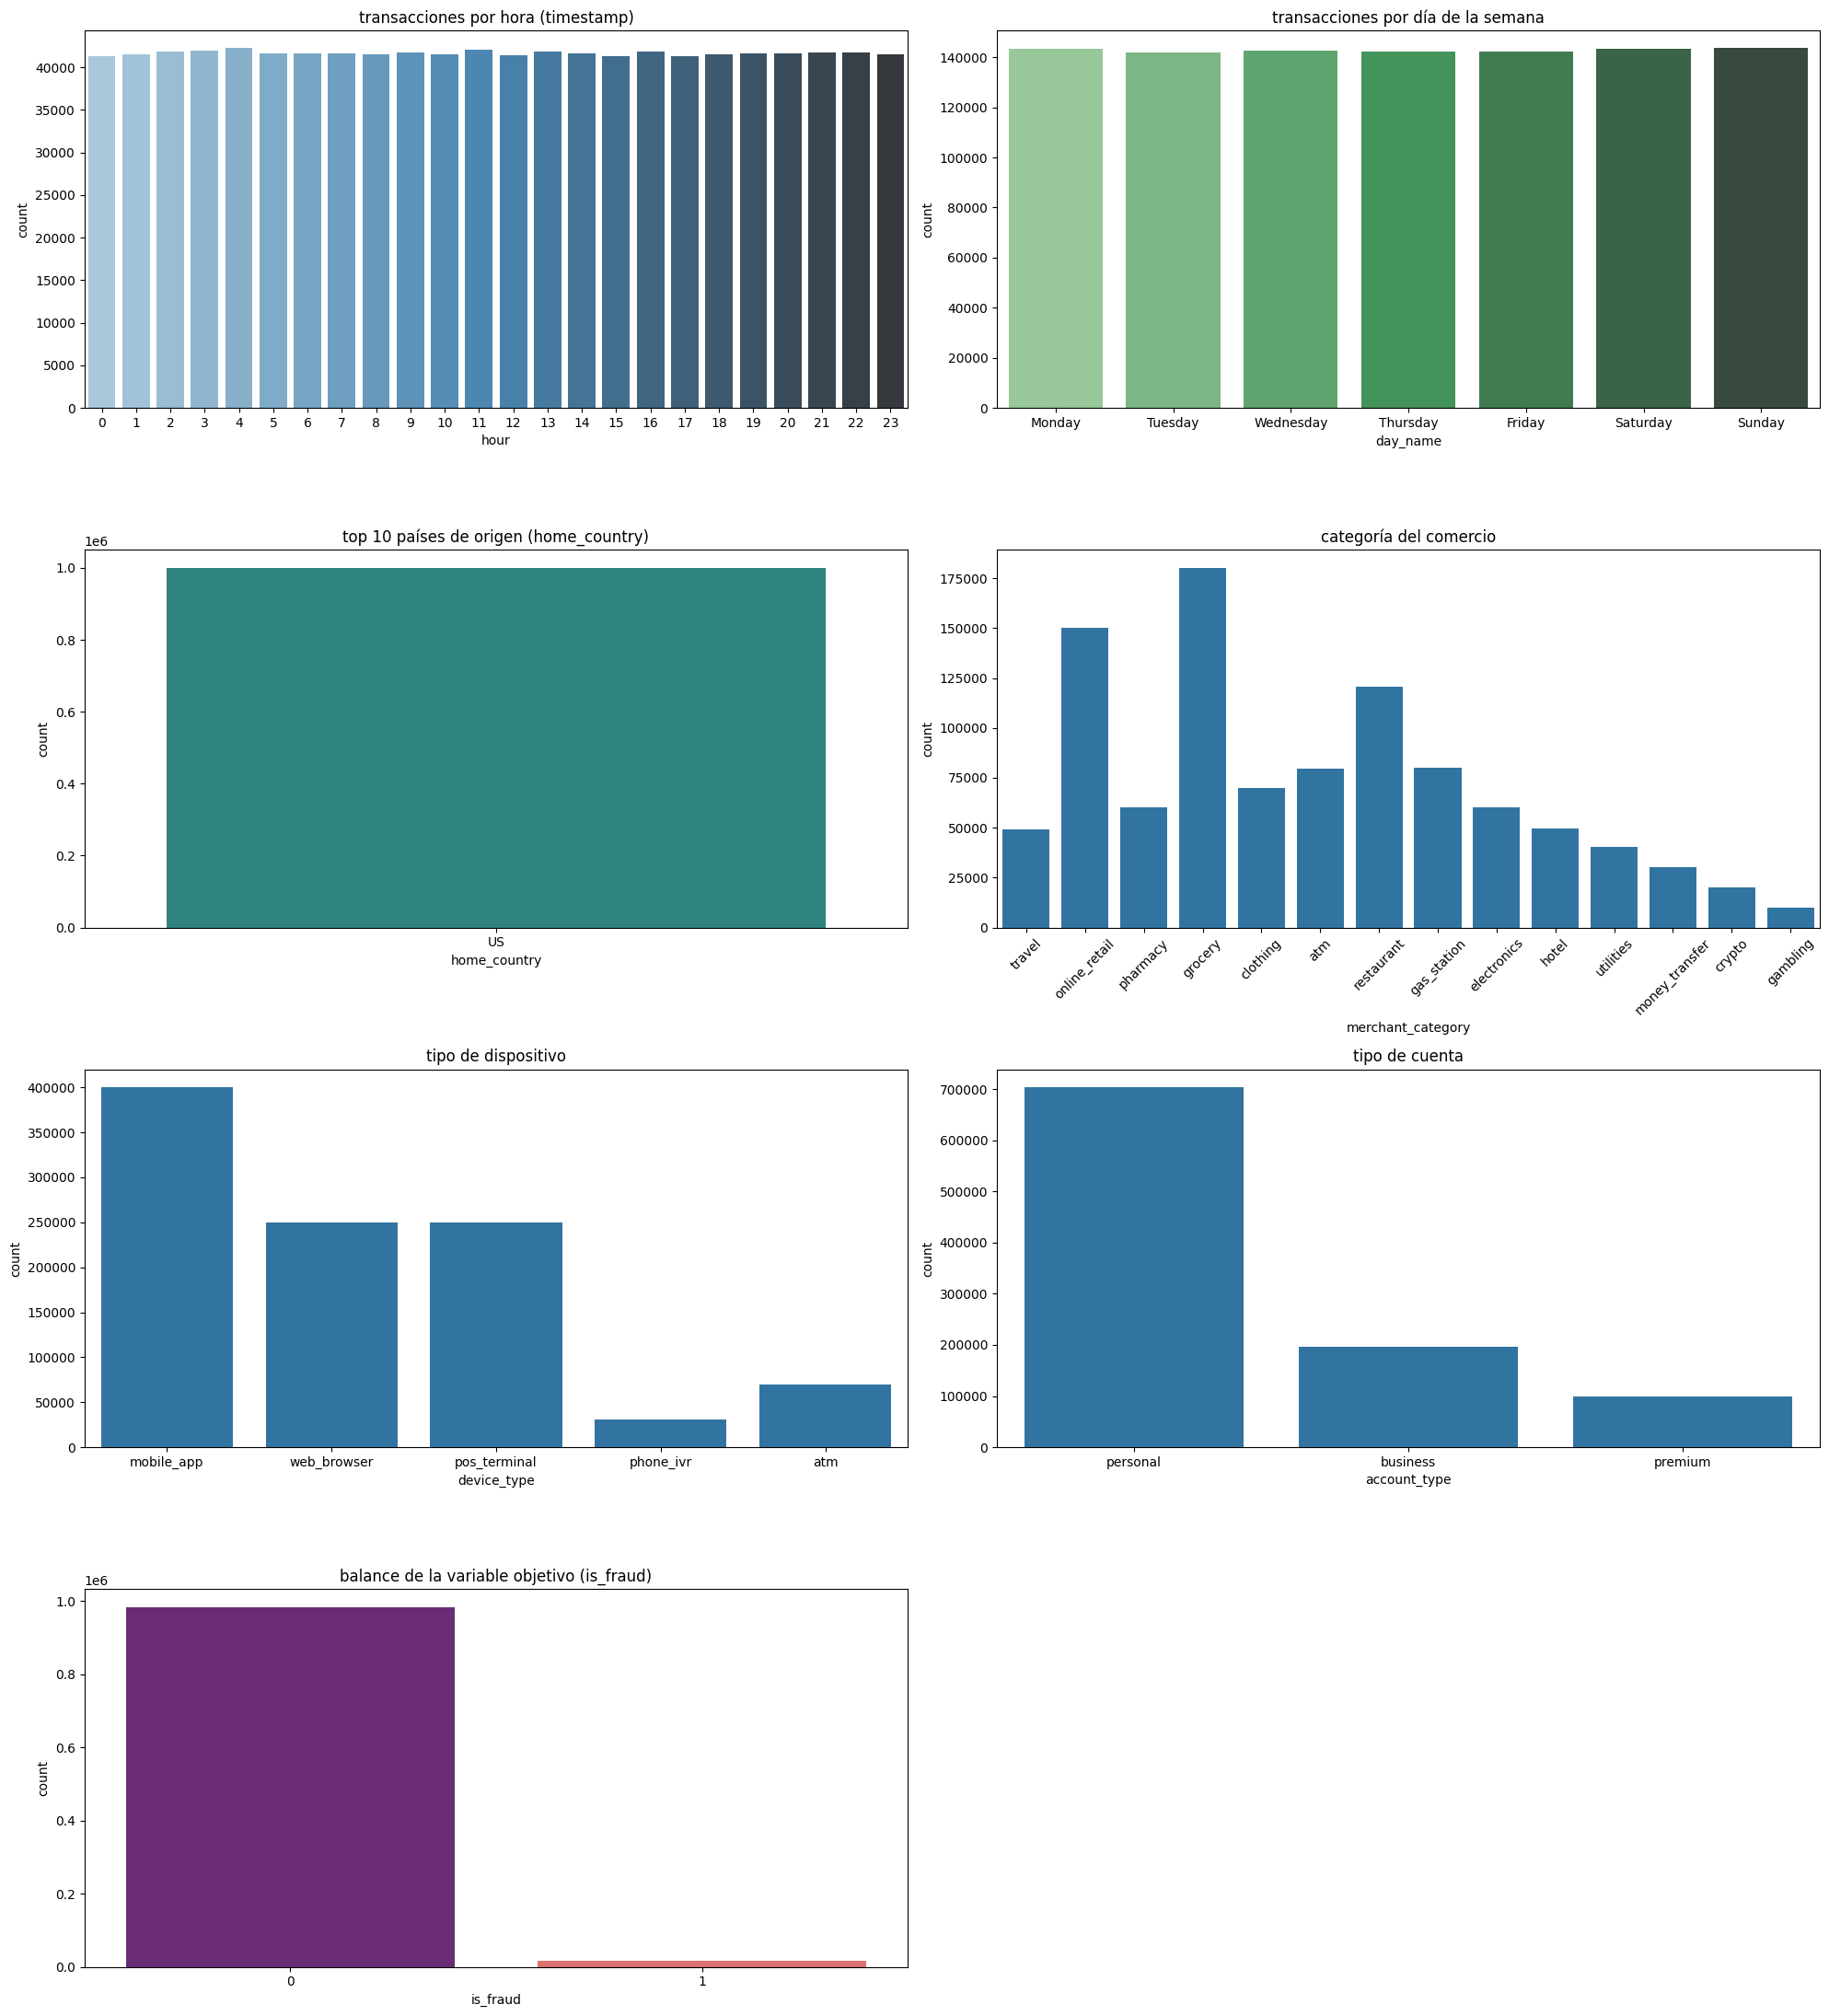

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. procesamiento de timestamp para las gráficas
df_final['timestamp'] = pd.to_datetime(df_final['timestamp'])
df_final['hour'] = df_final['timestamp'].dt.hour
df_final['day_name'] = df_final['timestamp'].dt.day_name()

# 2. configuramos el lienzo 4x2 para que quepan las 7 gráficas
fig, axis = plt.subplots(4, 2, figsize=(20, 22))

# --- fila 1: tiempo (timestamp) ---
sns.countplot(ax=axis[0, 0], data=df_final, x="hour", palette="Blues_d")
axis[0, 0].set_title("transacciones por hora (timestamp)")

orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(ax=axis[0, 1], data=df_final, x="day_name", order=orden_dias, palette="Greens_d")
axis[0, 1].set_title("transacciones por día de la semana")

# --- fila 2: geografía y comercio ---
# incluimos home_country nuevamente (top 10 para que sea legible)
top_paises = df_final['home_country'].value_counts().nlargest(10).index
sns.countplot(ax=axis[1, 0], data=df_final[df_final['home_country'].isin(top_paises)], x="home_country", palette="viridis")
axis[1, 0].set_title("top 10 países de origen (home_country)")

sns.countplot(ax=axis[1, 1], data=df_final, x="merchant_category")
axis[1, 1].set_title("categoría del comercio")
axis[1, 1].tick_params(axis='x', rotation=45)

# --- fila 3: dispositivos y cuenta ---
sns.countplot(ax=axis[2, 0], data=df_final, x="device_type")
axis[2, 0].set_title("tipo de dispositivo")

sns.countplot(ax=axis[2, 1], data=df_final, x="account_type")
axis[2, 1].set_title("tipo de cuenta")

# --- fila 4: variable objetivo ---
sns.countplot(ax=axis[3, 0], data=df_final, x="is_fraud", palette="magma")
axis[3, 0].set_title("balance de la variable objetivo (is_fraud)")

# apagamos el último eje para que no quede un cuadro blanco vacío
axis[3, 1].axis('off')

plt.tight_layout()
plt.show()

# Analisis
- Los datos estan desbalanceados
- la variable home country sera eliminada ya que no aporta nad al modelo
- La hora y el dia se comporta uniforme, no aporta nada al modelo

In [13]:
# aplicamos el filtro con las tres condiciones
df_fraude_usa_online = df_final[ 
    (df_final['merchant_category'] == 'online_retail') & 
    (df_final['home_country'] == 'US')
]

# verificamos cuántos casos encontramos
print(f"casos encontrados: {len(df_fraude_usa_online)}")

# mostramos los primeros resultados
df_fraude_usa_online

casos encontrados: 150118


,timestamp,hour_of_day,day_of_week,is_weekend,amount,merchant_category,mcc_code,merchant_country,card_present,device_type,...,avg_amount_y,median_amount,pct_night_0_5,pct_foreign_y,pct_card_not_present,avg_velocity_1h,avg_ip_risk_y,pct_no_2fa,hour,day_name
1,2024-05-12 23:13:34,23,6,1,85.78,online_retail,5999,AU,0,web_browser,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23,Sunday
4,2023-02-23 17:54:13,17,3,0,71.68,online_retail,5999,US,0,web_browser,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17,Thursday
15,2024-05-25 20:33:35,20,5,1,165.66,online_retail,5999,NG,0,web_browser,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20,Saturday
18,2024-05-11 17:28:14,17,5,1,124.63,online_retail,5999,US,1,atm,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17,Saturday
25,2023-11-12 07:51:40,7,6,1,43.71,online_retail,5999,DE,0,mobile_app,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999976,2023-05-29 18:10:34,18,0,0,119.23,online_retail,5999,US,1,pos_terminal,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18,Monday
999983,2024-09-20 01:31:56,1,4,0,105.70,online_retail,5999,US,0,web_browser,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,Friday
999987,2023-07-31 17:04:08,17,0,0,145.02,online_retail,5999,FR,0,mobile_app,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17,Monday
999989,2023-08-12 02:27:41,2,5,1,139.55,online_retail,5999,US,0,mobile_app,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,Saturday


In [14]:
df_fraude_usa_online.info()

<class 'pandas.DataFrame'>
Index: 150118 entries, 1 to 999996
Data columns (total 56 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   timestamp             150118 non-null  datetime64[us]
 1   hour_of_day           150118 non-null  int64         
 2   day_of_week           150118 non-null  int64         
 3   is_weekend            150118 non-null  int64         
 4   amount                150118 non-null  float64       
 5   merchant_category     150118 non-null  str           
 6   mcc_code              150118 non-null  int64         
 7   merchant_country      150118 non-null  str           
 8   card_present          150118 non-null  int64         
 9   device_type           150118 non-null  str           
 10  device_known          150118 non-null  int64         
 11  ip_risk_score         150118 non-null  float64       
 12  is_foreign_txn        150118 non-null  int64         
 13  time_since_last

# Análisis univariante - Numerico

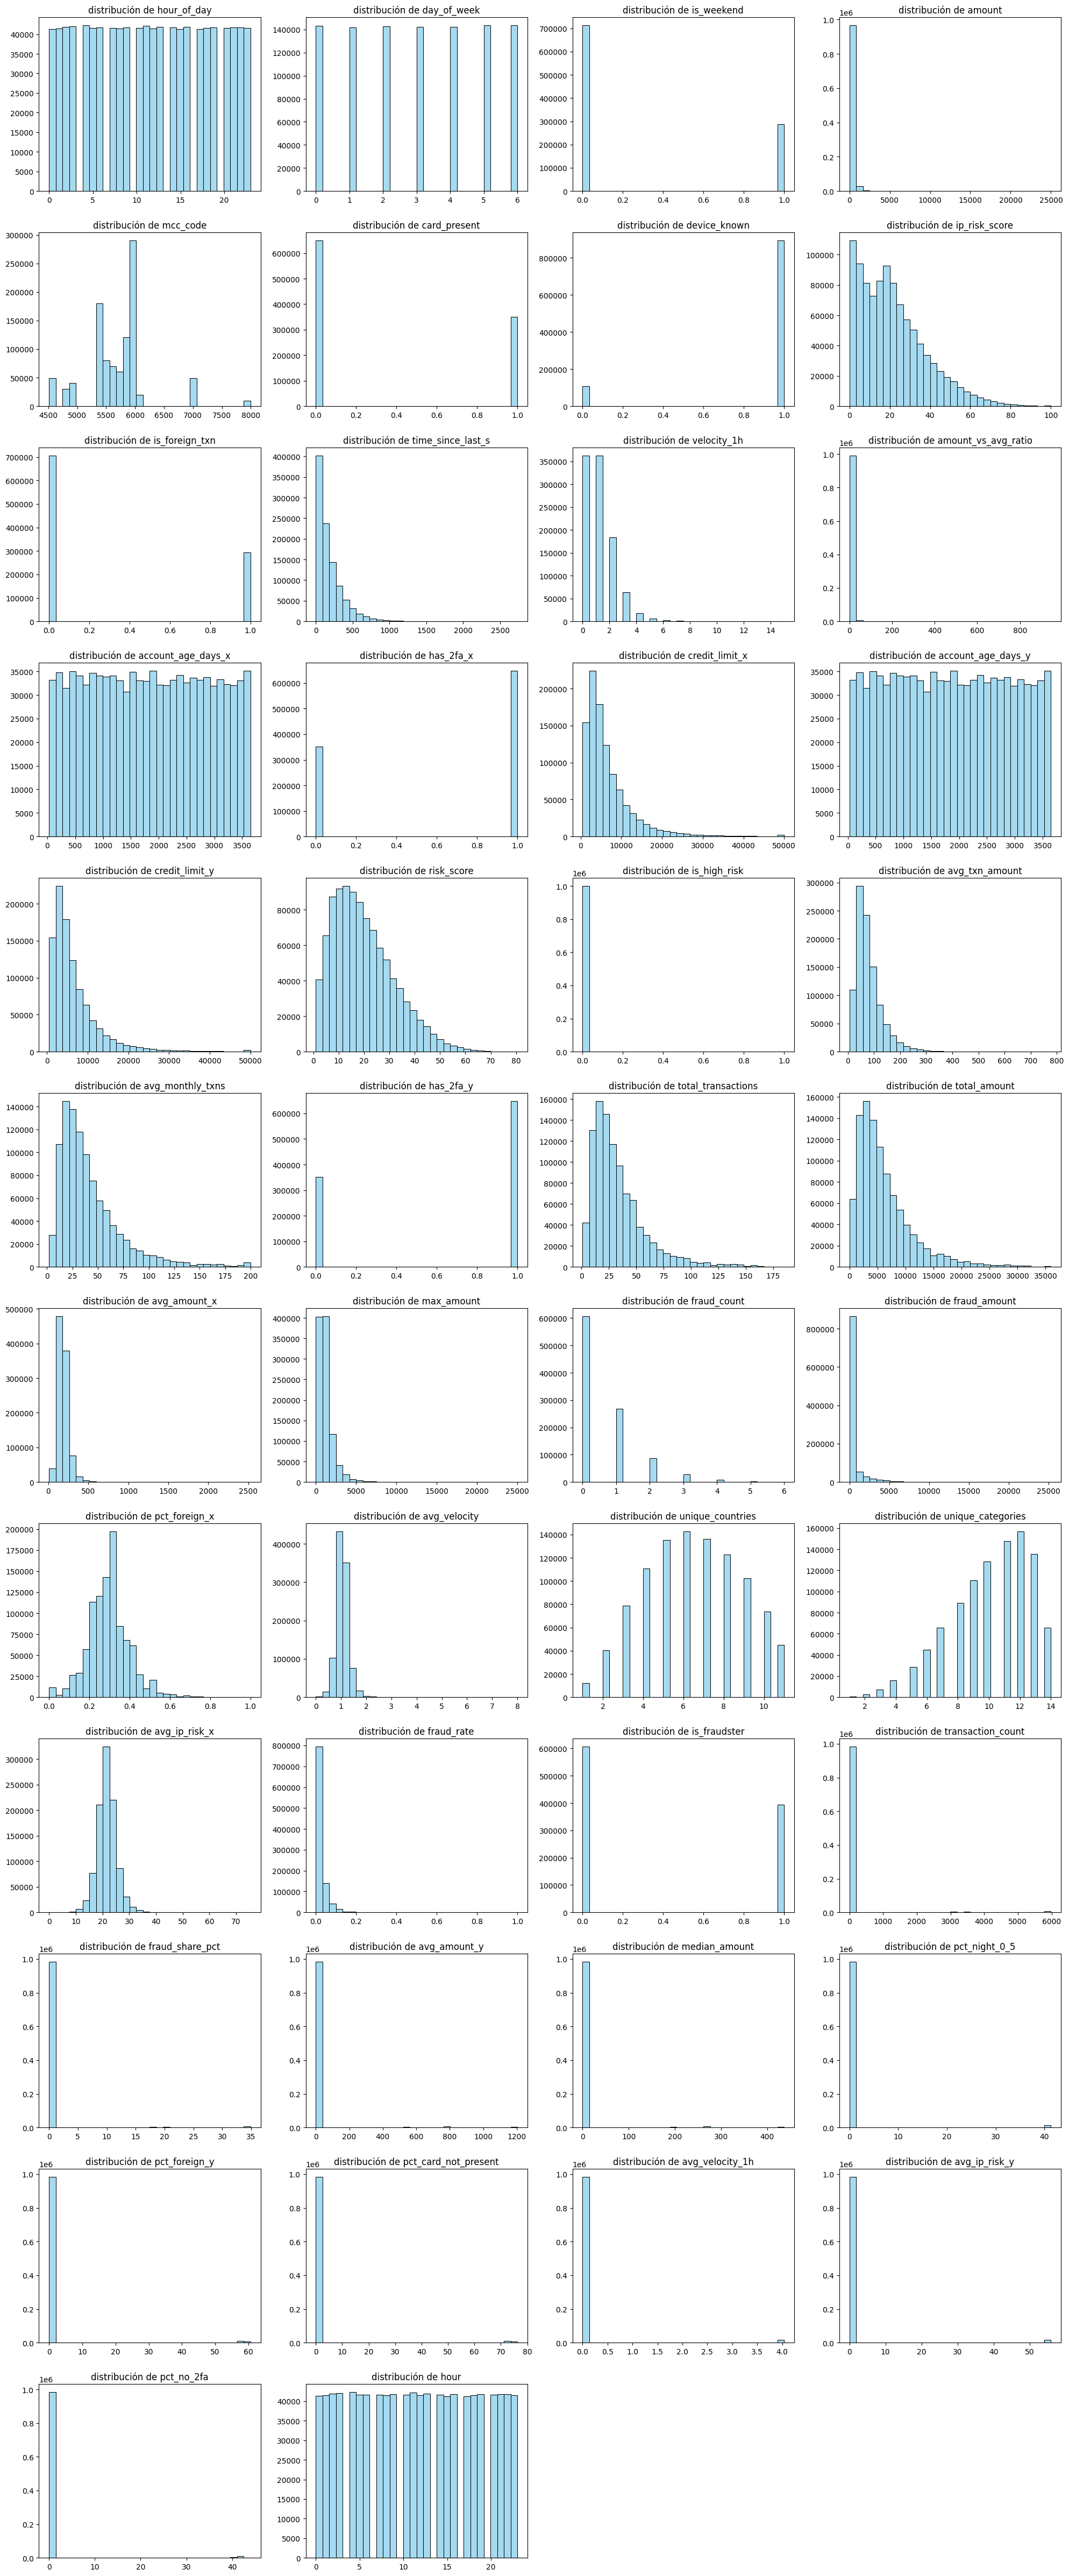

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. filtramos solo las columnas numéricas
# excluimos 'is_fraud' porque es el target y ya lo graficamos como categoría
variables_numericas = df_final.select_dtypes(include=['number']).columns.tolist()
if 'is_fraud' in variables_numericas:
    variables_numericas.remove('is_fraud')

# 2. configuramos la cuadrícula (grid)
# calculamos cuántas filas necesitamos para mostrar todas (ej. 4 columnas por fila)
cols_por_fila = 4
total_vars = len(variables_numericas)
filas = math.ceil(total_vars / cols_por_fila)

# 3. creamos los subplots
fig, axis = plt.subplots(filas, cols_por_fila, figsize=(20, filas * 4))
axis = axis.flatten() # aplanamos para iterar fácilmente

# 4. generamos los histogramas
for i, col in enumerate(variables_numericas):
    sns.histplot(ax=axis[i], data=df_final, x=col, bins=30, color='skyblue')
    axis[i].set_title(f"distribución de {col}")
    axis[i].set_xlabel("")
    axis[i].set_ylabel("")

# 5. apagamos los ejes que sobren
for j in range(i + 1, len(axis)):
    axis[j].axis('off')

plt.tight_layout()
plt.show()

In [16]:
variables_a_eliminar = [
    'fraud_rate', 'transaction_count', 'fraud_share_pct', 
    'avg_amount_y', 'median_amount', 'pct_night_0_5', 
    'pct_foreign_y', 'pct_card_not_present', 'avg_velocity_1h', 
    'avg_ip_risk_y', 'pct_no_2fa' , 'is_fraudster'
]

# el secreto es añadir errors='ignore'
df_fraude_usa_online = df_fraude_usa_online.drop(columns=variables_a_eliminar, errors='ignore')

df_fraude_usa_online

,timestamp,hour_of_day,day_of_week,is_weekend,amount,merchant_category,mcc_code,merchant_country,card_present,device_type,...,fraud_count,fraud_amount,pct_foreign_x,avg_velocity,unique_countries,unique_categories,avg_ip_risk_x,description,hour,day_name
1,2024-05-12 23:13:34,23,6,1,85.78,online_retail,5999,AU,0,web_browser,...,0.0,0.00,0.43,0.86,7.0,9.0,24.91,sin_informacion,23,Sunday
4,2023-02-23 17:54:13,17,3,0,71.68,online_retail,5999,US,0,web_browser,...,0.0,0.00,0.30,1.40,4.0,6.0,21.80,sin_informacion,17,Thursday
15,2024-05-25 20:33:35,20,5,1,165.66,online_retail,5999,NG,0,web_browser,...,0.0,0.00,0.48,1.10,9.0,11.0,20.73,sin_informacion,20,Saturday
18,2024-05-11 17:28:14,17,5,1,124.63,online_retail,5999,US,1,atm,...,0.0,0.00,0.32,1.04,6.0,10.0,17.77,sin_informacion,17,Saturday
25,2023-11-12 07:51:40,7,6,1,43.71,online_retail,5999,DE,0,mobile_app,...,2.0,537.47,0.50,1.50,4.0,5.0,35.22,sin_informacion,7,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999976,2023-05-29 18:10:34,18,0,0,119.23,online_retail,5999,US,1,pos_terminal,...,2.0,2962.87,0.22,1.29,9.0,14.0,24.71,sin_informacion,18,Monday
999983,2024-09-20 01:31:56,1,4,0,105.70,online_retail,5999,US,0,web_browser,...,0.0,0.00,0.15,0.93,5.0,14.0,19.89,sin_informacion,1,Friday
999987,2023-07-31 17:04:08,17,0,0,145.02,online_retail,5999,FR,0,mobile_app,...,0.0,0.00,0.25,1.17,4.0,6.0,19.63,sin_informacion,17,Monday
999989,2023-08-12 02:27:41,2,5,1,139.55,online_retail,5999,US,0,mobile_app,...,0.0,0.00,0.21,0.88,7.0,10.0,17.02,sin_informacion,2,Saturday


In [17]:
df_fraude_usa_online.info()

<class 'pandas.DataFrame'>
Index: 150118 entries, 1 to 999996
Data columns (total 44 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   timestamp            150118 non-null  datetime64[us]
 1   hour_of_day          150118 non-null  int64         
 2   day_of_week          150118 non-null  int64         
 3   is_weekend           150118 non-null  int64         
 4   amount               150118 non-null  float64       
 5   merchant_category    150118 non-null  str           
 6   mcc_code             150118 non-null  int64         
 7   merchant_country     150118 non-null  str           
 8   card_present         150118 non-null  int64         
 9   device_type          150118 non-null  str           
 10  device_known         150118 non-null  int64         
 11  ip_risk_score        150118 non-null  float64       
 12  is_foreign_txn       150118 non-null  int64         
 13  time_since_last_s    150118 no

# Analisis Multivariante

 Numerico - Numerico

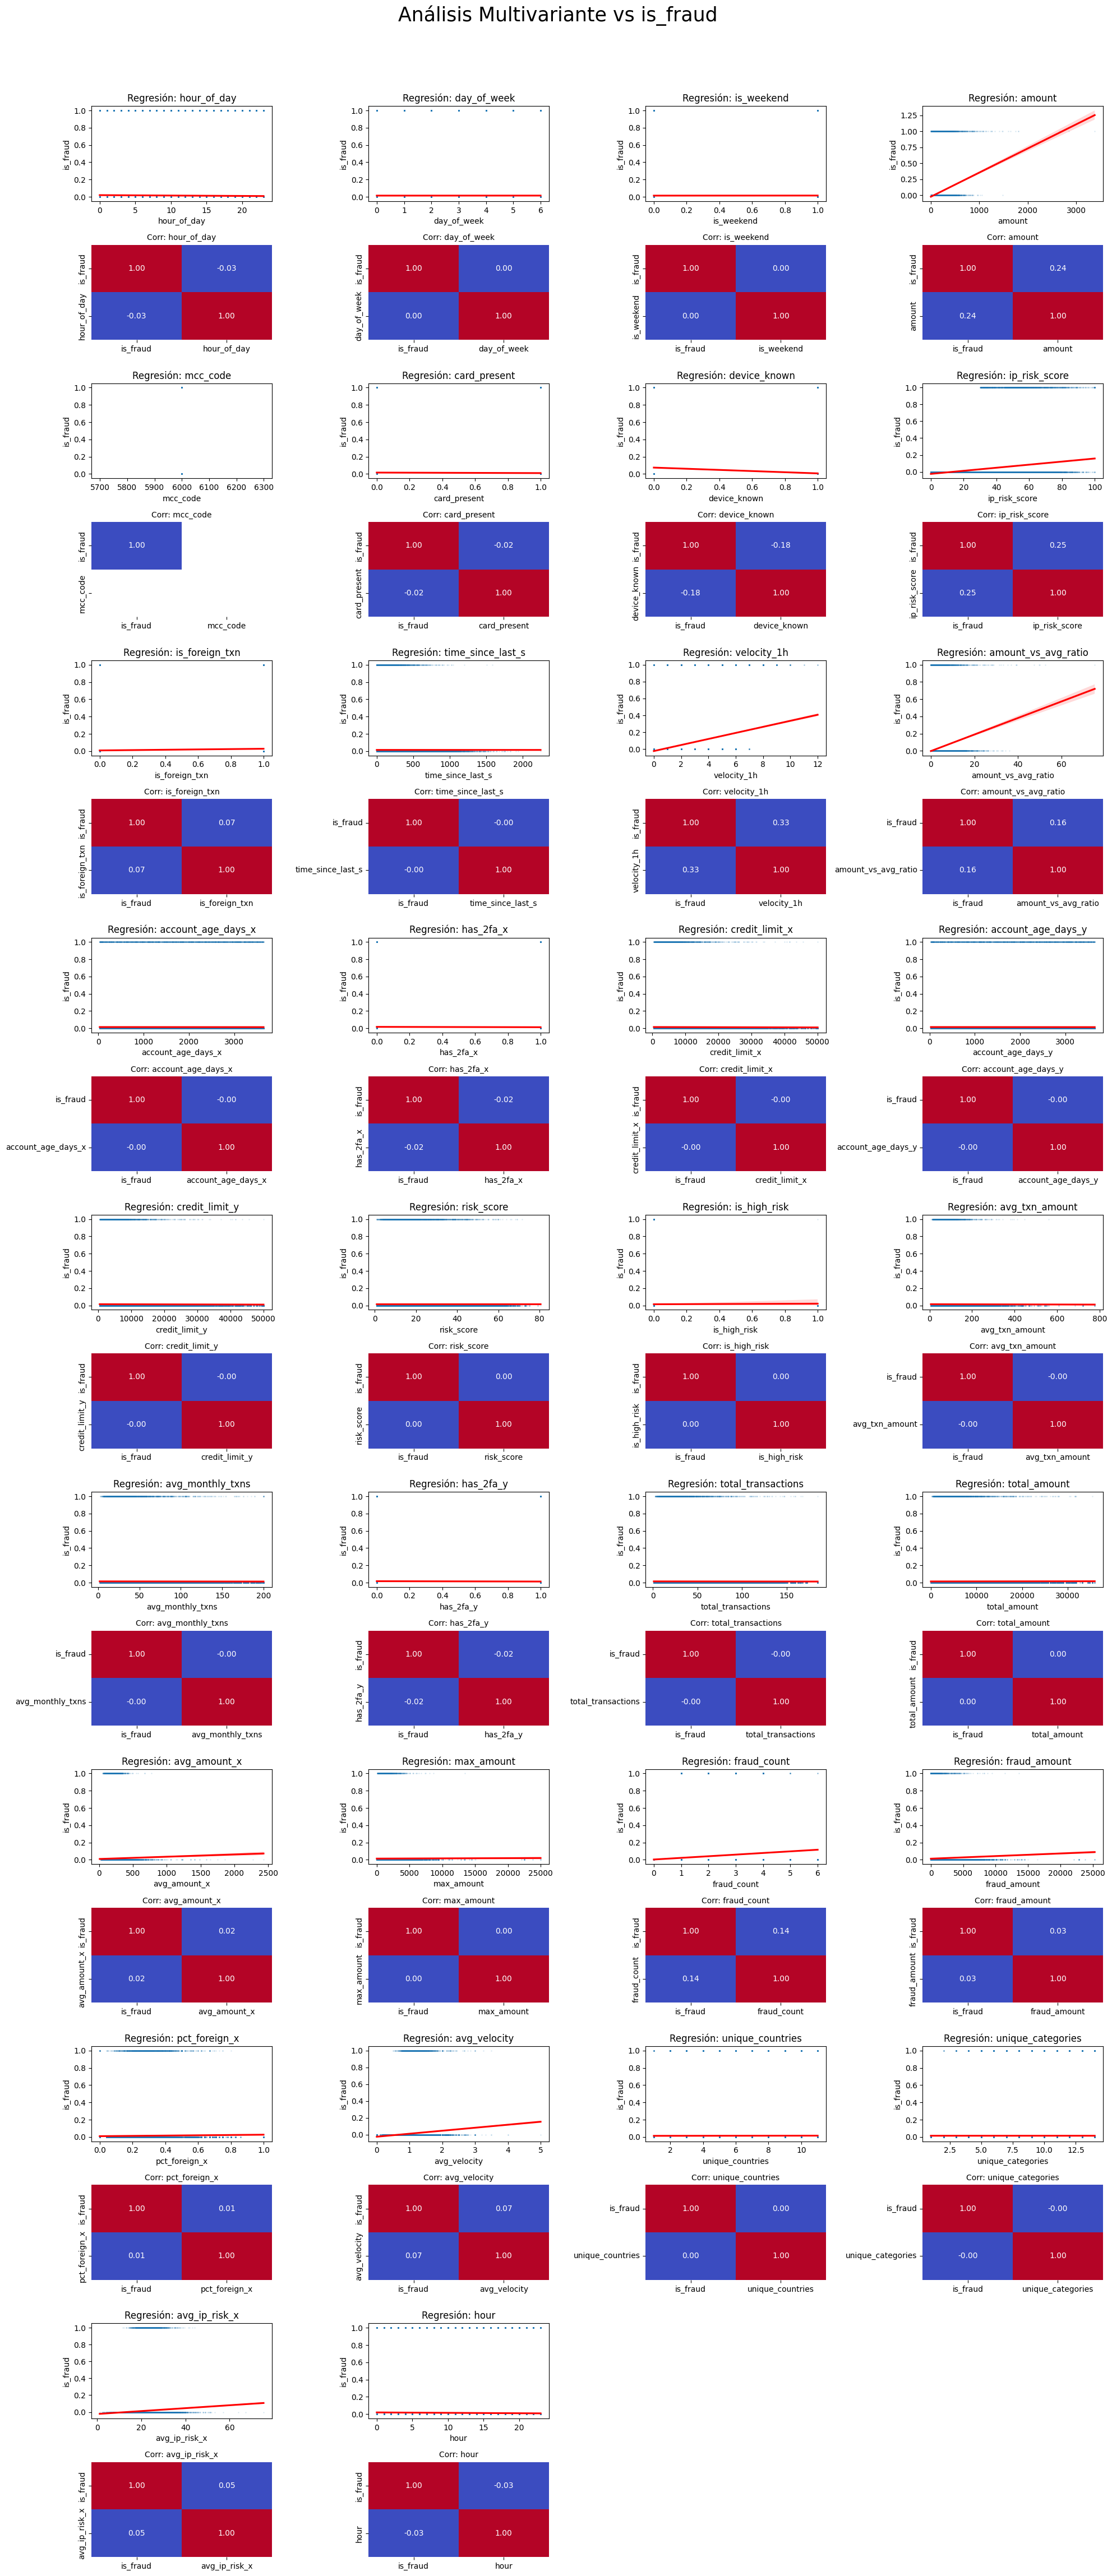

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/vscode/.local/lib/python3.11/site-packages/ipykernel/iostream.py", line 105, in _handle_subscription
    event_type = frame[0]
                 ~~~~~^^^
IndexError: index out of range
ERROR:tornado.general:Uncaught exception in zmqstream callback
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 600, in _handle_events
    self._handle_recv()
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 629, in _handle_recv
    self._run_callback(callback, msg)
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, 

: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Configuración de variables
df = df_fraude_usa_online
target = 'is_fraud'
# Seleccionamos solo las numéricas y quitamos el target
numeric_cols = df.select_dtypes(include=['number']).columns.drop(target)

# 2. Configuración de la cuadrícula (Subplots)
cols_per_row = 4  # Número de variables por fila
num_vars = len(numeric_cols)
num_rows = math.ceil(num_vars / cols_per_row)

# Creamos la figura. Multiplicamos num_rows por 2 porque cada variable 
# ocupa 2 subplots verticales (regplot + heatmap)
fig, axis = plt.subplots(num_rows * 2, cols_per_row, figsize=(20, 5 * num_rows))
fig.suptitle(f'Análisis Multivariante vs {target}', fontsize=25, y=1.02)

# 3. Bucle para llenar los subplots
for i, col_name in enumerate(numeric_cols):
    # Calculamos la posición en la cuadrícula
    row = (i // cols_per_row) * 2
    col = i % cols_per_row
    
    # --- Gráfico de Regresión (Fila Superior del par) ---
    sns.regplot(ax=axis[row, col], data=df, x=col_name, y=target, 
                scatter_kws={'alpha':0.1, 's':1}, line_kws={'color':'red'})
    axis[row, col].set_title(f"Regresión: {col_name}", fontsize=12)
    
    # --- Mapa de Calor (Fila Inferior del par) ---
    corr_matrix = df[[target, col_name]].corr()
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", ax=axis[row+1, col], 
                cbar=False, cmap="coolwarm")
    axis[row+1, col].set_title(f"Corr: {col_name}", fontsize=10)

# 4. Limpieza: Ocultar subplots vacíos si el número de variables no es exacto
for j in range(i + 1, num_rows * cols_per_row):
    row_empty = (j // cols_per_row) * 2
    col_empty = j % cols_per_row
    axis[row_empty, col_empty].axis('off')
    axis[row_empty + 1, col_empty].axis('off')

# Ajustar el layout para que no se solapen
plt.tight_layout()
plt.show()

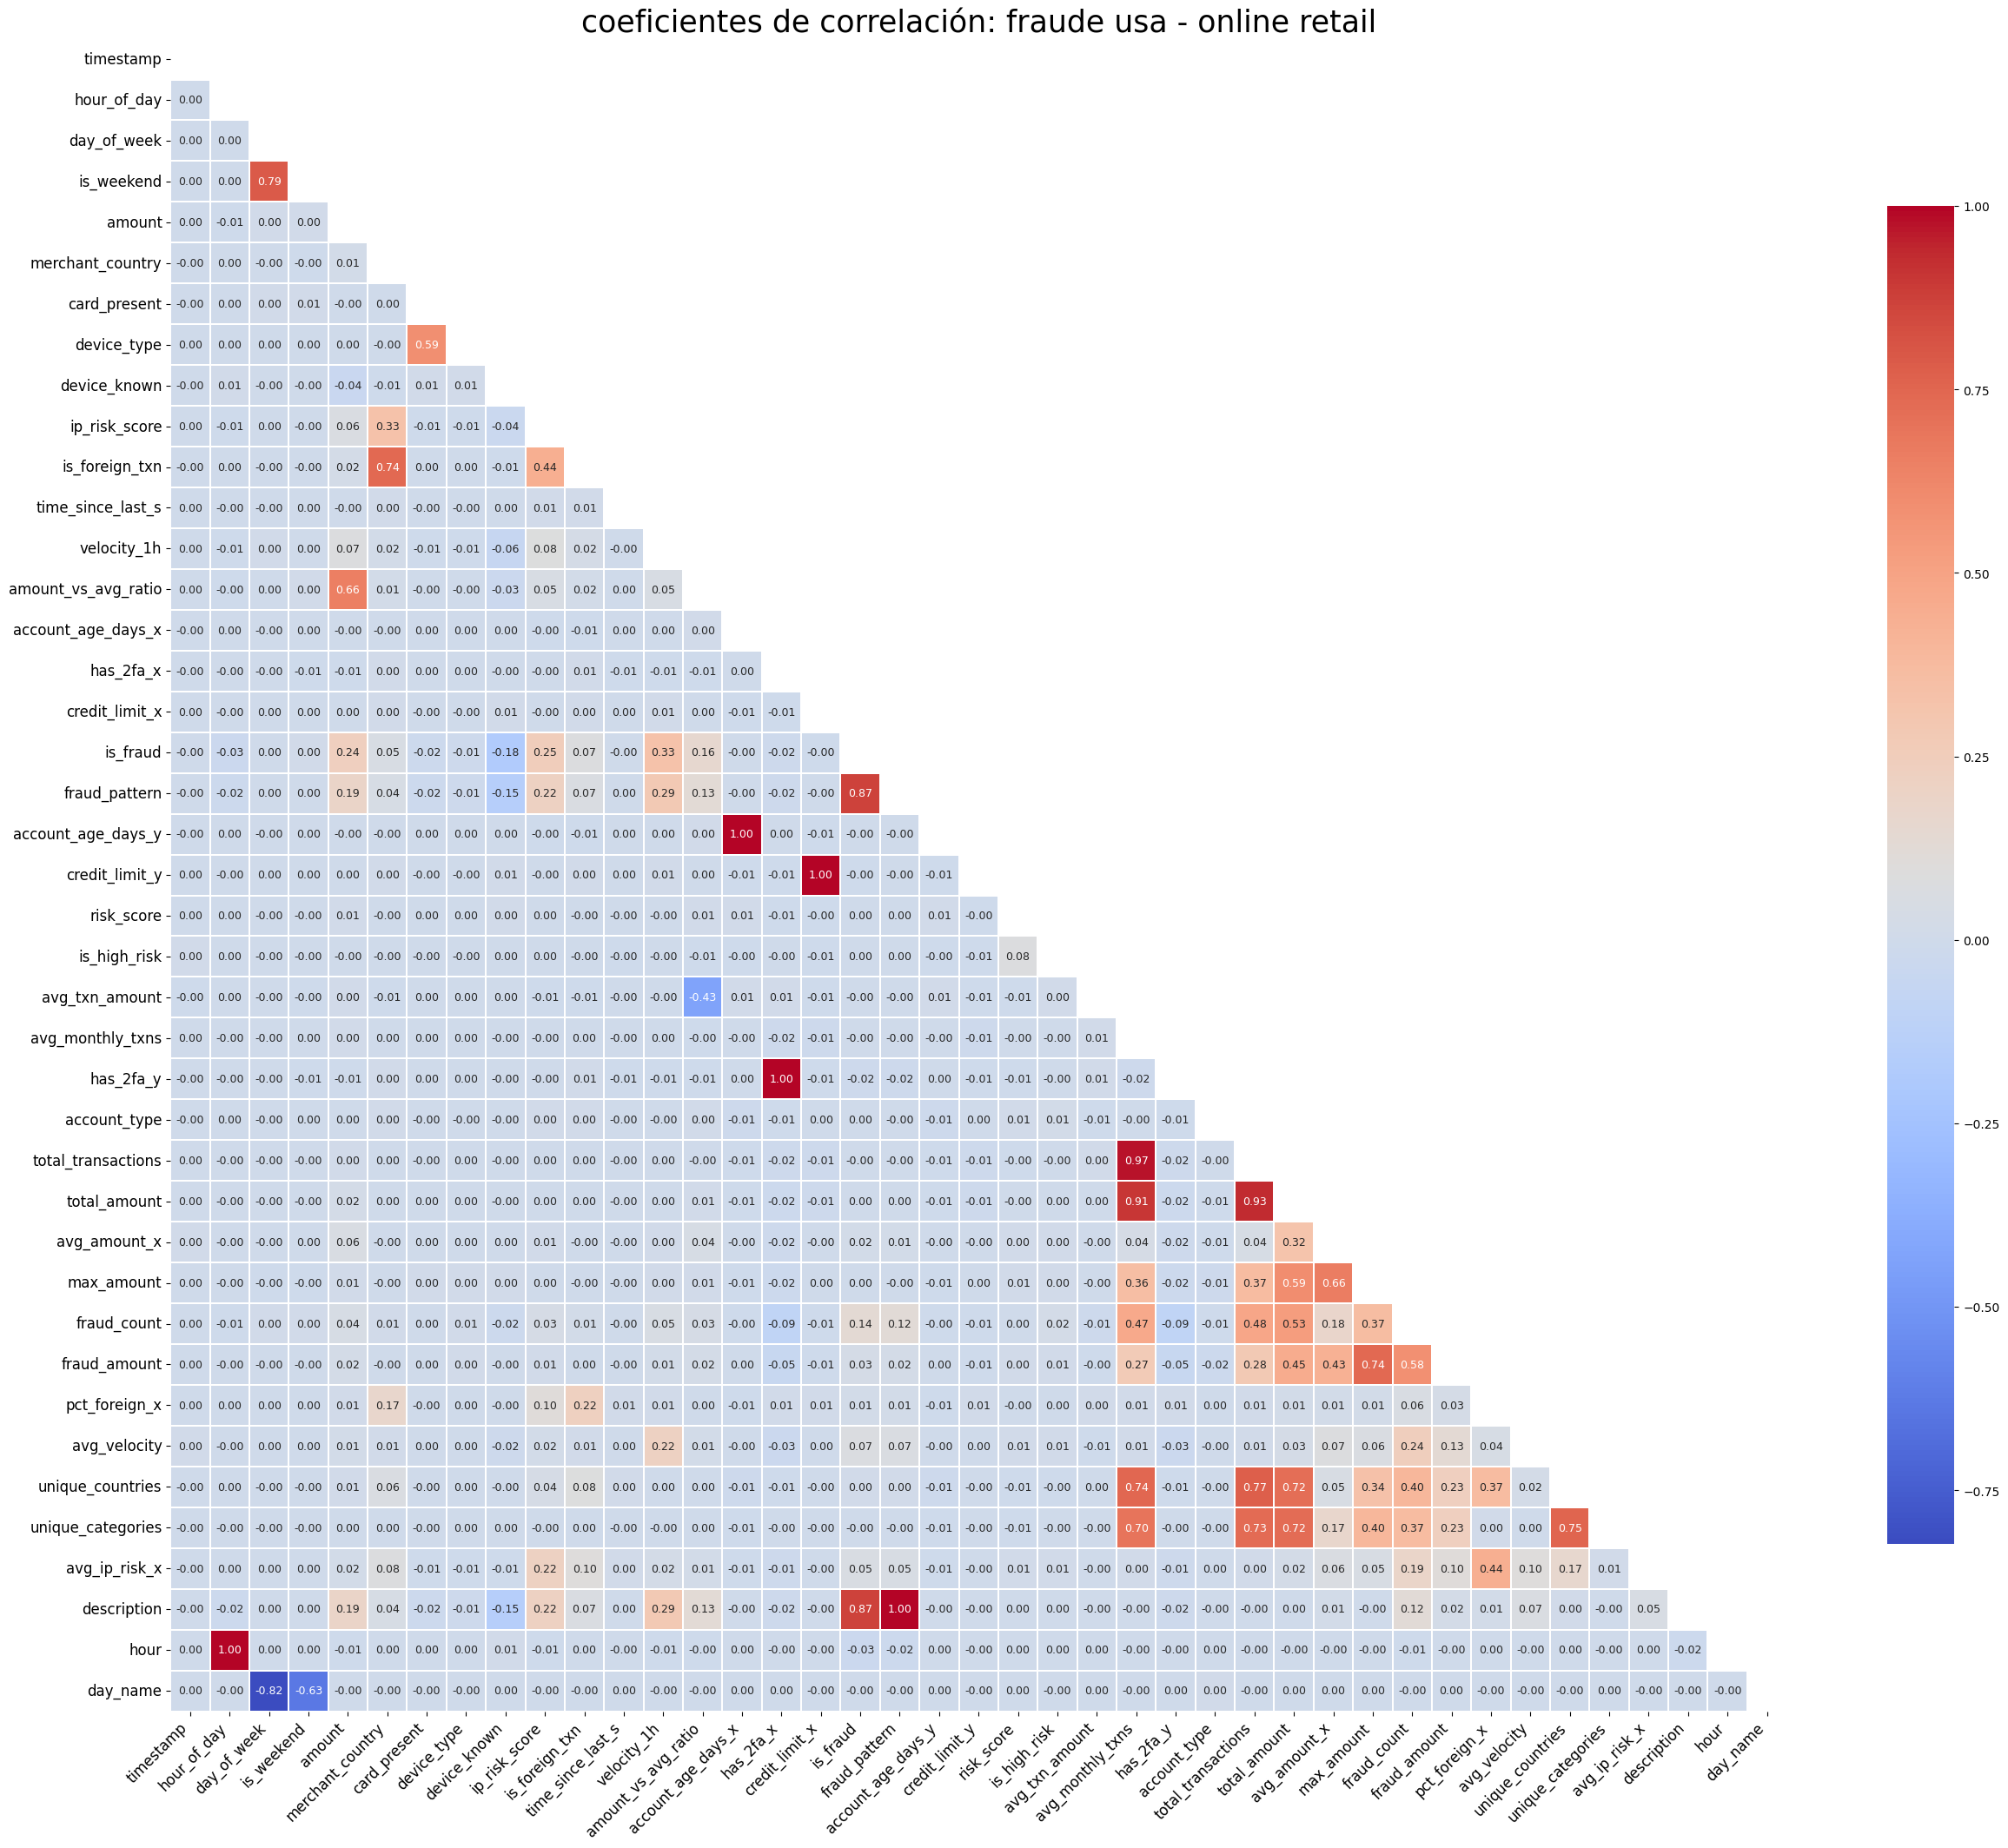

In [ ]:
import numpy as np

# 1. preparamos los datos (factorizando y limpiando constantes)
df_corr_final = df_fraude_usa_online.copy()
for col in df_corr_final.select_dtypes(include=['object', 'string']).columns:
    df_corr_final[col] = pd.factorize(df_corr_final[col])[0]

# nos quedamos solo con variables que varían (importante para evitar NaNs)
df_corr_final = df_corr_final.loc[:, df_corr_final.nunique() > 1]

# 2. calculamos la matriz
corr_matrix = df_corr_final.corr()

# 3. CREAMOS UNA MÁSCARA para ocultar la parte superior repetida
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. configuramos el mapa de calor con los coeficientes visibles
plt.figure(figsize=(30, 25))

sns.heatmap(
    corr_matrix, 
    mask=mask,               # aplicamos la máscara
    annot=True,              # MOSTRAR COEFICIENTES
    fmt=".2f",               # dos decimales
    cmap='coolwarm',         # escala de color azul-rojo
    annot_kws={"size": 9},    # tamaño de fuente de los números
    cbar_kws={"shrink": .8},
    linewidths=0.1
)

plt.title("coeficientes de correlación: fraude usa - online retail", fontsize=25)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# Ingenieria de Caracteristicas

In [19]:
# 1. identificamos columnas numéricas primero para no fallar con strings
columnas_num = df_fraude_usa_online.select_dtypes(include=['number']).columns

# 2. calculamos correlación uno a uno (esto ahorra mucha ram)
correlaciones = {}
for col in columnas_num:
    if col != 'is_fraud':
        correlaciones[col] = df_fraude_usa_online['is_fraud'].corr(df_final[col])

# 3. convertimos a serie para manipular fácil
series_corr = pd.Series(correlaciones).sort_values(ascending=False)

# 4. filtramos las que tengan un impacto real (mayor a 0.1 absoluto)
top_impacto = series_corr[abs(series_corr) > 0.1]

print("variables con mayor impacto en is_fraud:")
print(top_impacto)

/home/vscode/.local/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/vscode/.local/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


variables con mayor impacto en is_fraud:
velocity_1h            0.328678
ip_risk_score          0.249843
amount                 0.237859
amount_vs_avg_ratio    0.159617
fraud_count            0.137135
device_known          -0.175089
dtype: float64


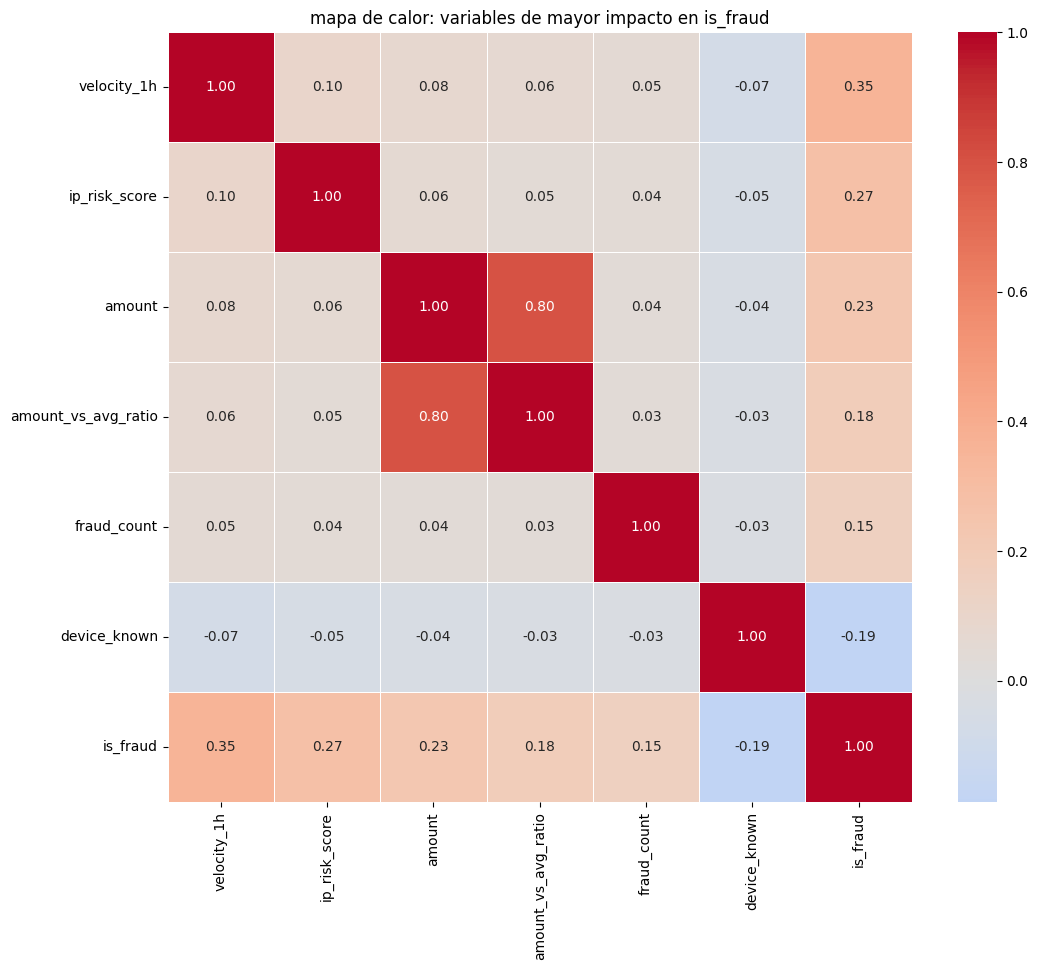

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. definimos la lista basada en tus resultados de mayor impacto
variables_impacto = [
    'velocity_1h', 'ip_risk_score', 'amount', 
    'amount_vs_avg_ratio', 'fraud_count', 'device_known'
]

# 2. calculamos la matriz de correlación solo para estas variables
# usamos df_final para asegurar que is_fraud tenga variación
df_reducido = df_final[variables_impacto + ['is_fraud']]
matriz_impacto = df_reducido.corr()

# 3. creamos el mapa de calor
plt.figure(figsize=(12, 10))

sns.heatmap(
    matriz_impacto, 
    annot=True,          # mostramos los coeficientes exactos
    fmt=".2f", 
    cmap='coolwarm',     # rojo para pos, azul para neg
    center=0,
    linewidths=0.5
)

plt.title("mapa de calor: variables de mayor impacto en is_fraud")
plt.show()

In [21]:
# 1. Definimos la lista final de variables seleccionadas por su alto impacto
# Incluimos 'is_fraud' como nuestra variable objetivo (target)
variables_finales = [
    'velocity_1h', 
    'ip_risk_score', 
    'amount', 
    'amount_vs_avg_ratio', 
    'fraud_count', 
    'device_known',
    'is_fraud'
]

# 2. Creamos el dataframe de trabajo
# Usamos df_final para mantener la representatividad de ambos casos (0 y 1)
df_modelo =df_fraude_usa_online[variables_finales].copy()

# 3. Verificación rápida
print(f"Dimensiones del nuevo dataframe: {df_modelo.shape}")
print("\nPrimeras filas del set de entrenamiento:")
display(df_modelo.head())

# 4. Revisión de nulos (importante antes del boosting)
print("\nConteo de valores nulos:")
print(df_modelo.isnull().sum())

Dimensiones del nuevo dataframe: (150118, 7)

Primeras filas del set de entrenamiento:


,velocity_1h,ip_risk_score,amount,amount_vs_avg_ratio,fraud_count,device_known,is_fraud
1,1,25.3,85.78,0.7279,0.0,1,0
4,2,9.7,71.68,0.7724,0.0,1,0
15,0,33.0,165.66,3.4199,0.0,1,0
18,2,4.5,124.63,0.9420,0.0,1,0
25,1,54.2,43.71,1.1579,2.0,0,0



Conteo de valores nulos:
velocity_1h            0
ip_risk_score          0
amount                 0
amount_vs_avg_ratio    0
fraud_count            0
device_known           0
is_fraud               0
dtype: int64


In [22]:
# eliminamos fraud_count para evitar data leakage
df_modelo = df_modelo.drop(columns=['fraud_count'])

In [23]:
df_modelo

,velocity_1h,ip_risk_score,amount,amount_vs_avg_ratio,device_known,is_fraud
1,1,25.3,85.78,0.7279,1,0
4,2,9.7,71.68,0.7724,1,0
15,0,33.0,165.66,3.4199,1,0
18,2,4.5,124.63,0.9420,1,0
25,1,54.2,43.71,1.1579,0,0
...,...,...,...,...,...,...
999976,0,3.9,119.23,2.3971,1,0
999983,2,23.6,105.70,1.1843,1,0
999987,0,17.8,145.02,2.9748,1,0
999989,0,22.2,139.55,1.4129,1,0


In [24]:
df_modelo.describe()

,velocity_1h,ip_risk_score,amount,amount_vs_avg_ratio,device_known,is_fraud
count,150118.000000,150118.000000,150118.000000,150118.000000,150118.000000,150118.000000
mean,1.043126,21.450001,103.871636,1.856127,0.893304,0.014129
std,1.081443,16.152493,74.253166,1.957227,0.308727,0.118023
min,0.000000,0.000000,3.130000,0.037200,0.000000,0.000000
25%,0.000000,8.400000,56.930000,0.727200,1.000000,0.000000
50%,1.000000,18.600000,85.700000,1.282000,1.000000,0.000000
75%,2.000000,30.500000,128.880000,2.284800,1.000000,0.000000
max,12.000000,100.000000,3378.310000,75.189300,1.000000,1.000000


Analisis de Outiliers

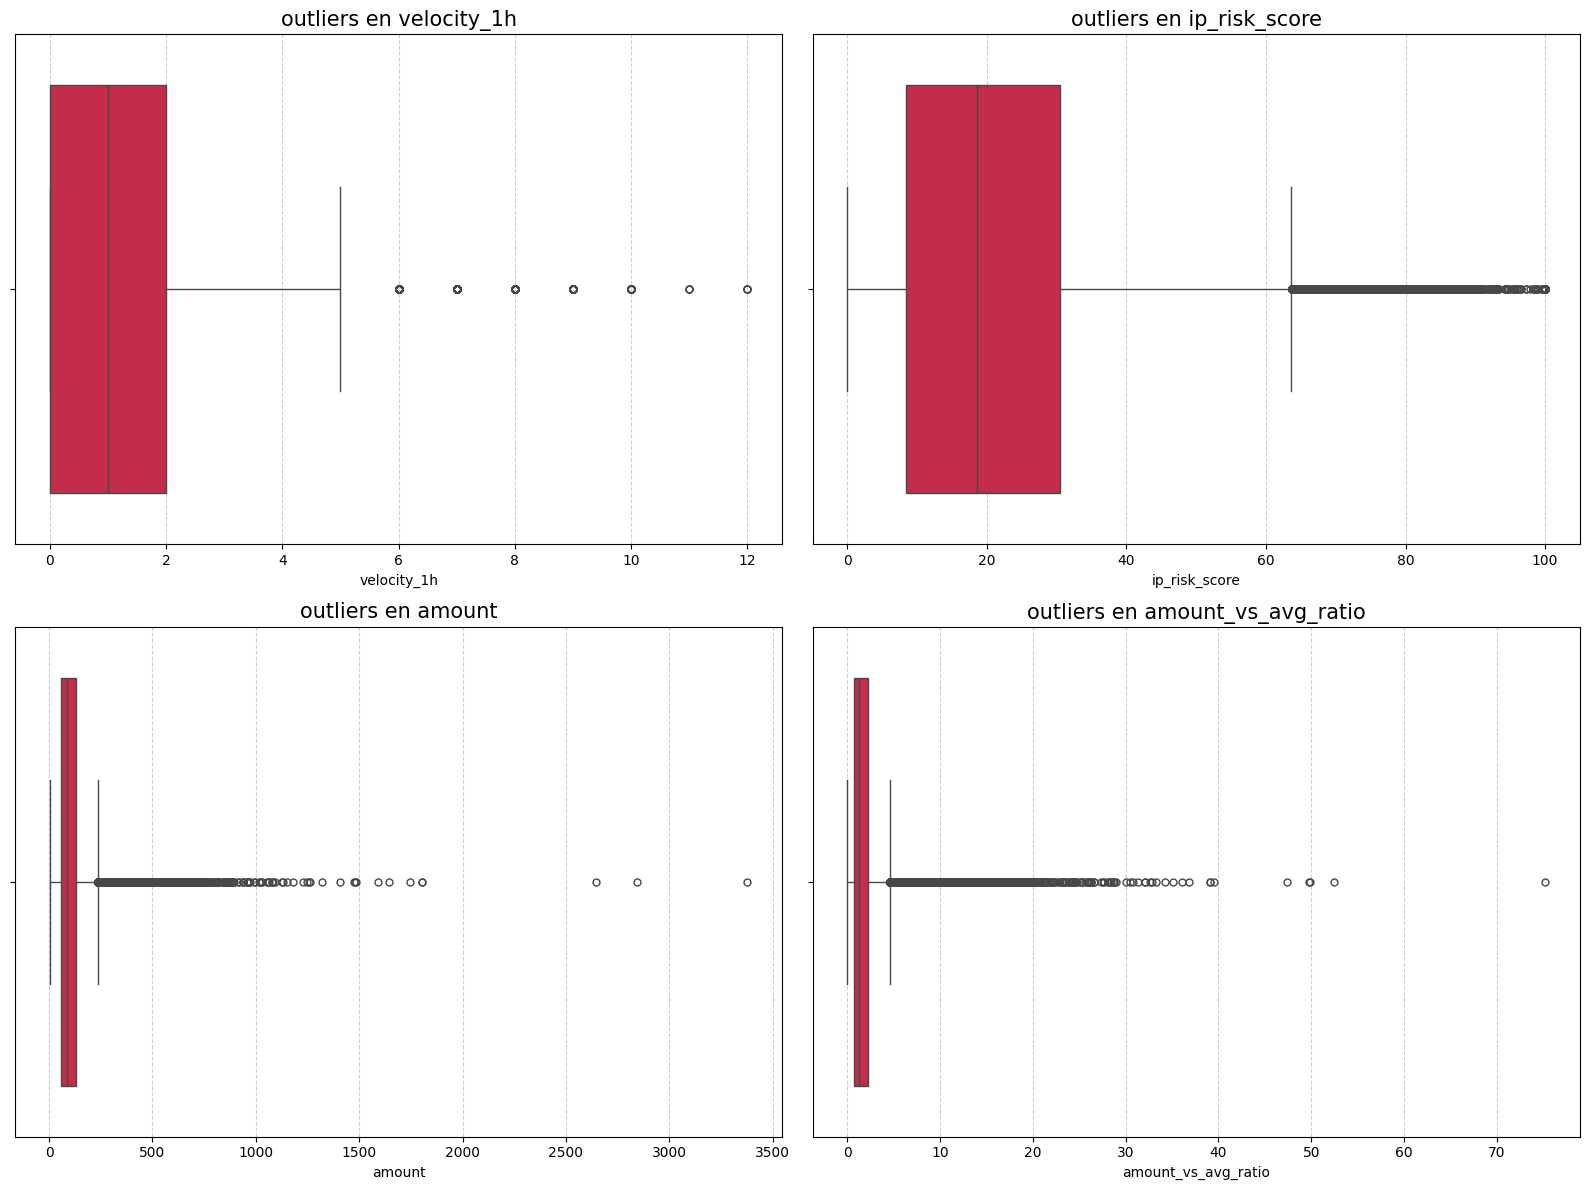

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definimos las variables a graficar
vars_interes = ['velocity_1h', 'ip_risk_score', 'amount', 'amount_vs_avg_ratio']

# 2. Creamos la cuadrícula de 2x2
fig, axis = plt.subplots(2, 2, figsize=(16, 12))

# 3. Generamos cada boxplot automáticamente
for i, var in enumerate(vars_interes):
    fila = i // 2
    columna = i % 2
    
    sns.boxplot(ax=axis[fila, columna], data=df_modelo, x=var, color='crimson', fliersize=5)
    axis[fila, columna].set_title(f'outliers en {var}', fontsize=15)
    axis[fila, columna].grid(axis='x', linestyle='--', alpha=0.6)

# Ajustamos el diseño para que no se pisen los títulos
plt.tight_layout()
plt.show()

In [26]:
# 1. Definimos las variables a limpiar
vars_limpieza = ['velocity_1h', 'ip_risk_score', 'amount', 'amount_vs_avg_ratio']


# 2. Aplicamos el filtro para cada variable
for var in vars_limpieza:
    Q1 = df_modelo[var].quantile(0.25)
    Q3 = df_modelo[var].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Filtramos: nos quedamos solo con lo que está dentro de los límites
    df_modelo = df_modelo[(df_modelo[var] >= limite_inferior) & (df_modelo[var] <= limite_superior)]


df_modelo



,velocity_1h,ip_risk_score,amount,amount_vs_avg_ratio,device_known,is_fraud
1,1,25.3,85.78,0.7279,1,0
4,2,9.7,71.68,0.7724,1,0
15,0,33.0,165.66,3.4199,1,0
18,2,4.5,124.63,0.9420,1,0
25,1,54.2,43.71,1.1579,0,0
...,...,...,...,...,...,...
999969,3,2.5,69.43,0.8189,1,0
999976,0,3.9,119.23,2.3971,1,0
999983,2,23.6,105.70,1.1843,1,0
999987,0,17.8,145.02,2.9748,1,0


In [27]:
df_modelo.isnull().sum()

velocity_1h            0
ip_risk_score          0
amount                 0
amount_vs_avg_ratio    0
device_known           0
is_fraud               0
dtype: int64

In [28]:
df_modelo.info()

<class 'pandas.DataFrame'>
Index: 131616 entries, 1 to 999989
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   velocity_1h          131616 non-null  int64  
 1   ip_risk_score        131616 non-null  float64
 2   amount               131616 non-null  float64
 3   amount_vs_avg_ratio  131616 non-null  float64
 4   device_known         131616 non-null  int64  
 5   is_fraud             131616 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 7.0 MB


In [29]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Definimos las variables numéricas (excluyendo el target)
num_variables = ['velocity_1h', 'ip_risk_score', 'amount', 'amount_vs_avg_ratio', 'device_known']

# 2. Inicializamos el StandardScaler
scaler = StandardScaler()

# 3. Ajustamos y transformamos los datos
# Usamos df_modelo directamente para sobrescribir los valores
df_modelo[num_variables] = scaler.fit_transform(df_modelo[num_variables])

# 4. Verificamos el resultado
print("Estadísticas tras el StandardScaler (Media ≈ 0, Desviación ≈ 1):")
display(df_modelo[num_variables].describe().round(2))

print("\nPrimeras filas del dataframe escalado:")
display(df_modelo.head())


Estadísticas tras el StandardScaler (Media ≈ 0, Desviación ≈ 1):


,velocity_1h,ip_risk_score,amount,amount_vs_avg_ratio,device_known
count,131616.00,131616.00,131616.00,131616.00,131616.00
mean,-0.00,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-1.00,-1.40,-1.89,-1.48,-2.95
25%,-1.00,-0.84,-0.76,-0.78,0.34
50%,-0.01,-0.14,-0.20,-0.26,0.34
75%,0.98,0.62,0.57,0.56,0.34
max,3.96,2.95,3.26,3.10,0.34



Primeras filas del dataframe escalado:


,velocity_1h,ip_risk_score,amount,amount_vs_avg_ratio,device_known,is_fraud
1,-0.008929,0.344818,-0.055277,-0.716807,0.338423,0
4,0.984517,-0.730589,-0.368071,-0.667859,0.338423,0
15,-1.002375,0.875628,1.716776,2.244305,0.338423,0
18,0.984517,-1.089058,0.806569,-0.481304,0.338423,0
25,-0.008929,2.337078,-0.988556,-0.243821,-2.954879,0


In [30]:
from sklearn.model_selection import train_test_split

x = df_modelo.drop('is_fraud', axis=1)
y = df_modelo['is_fraud']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

/home/vscode/.local/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [20:36:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- reporte de clasificación ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26193
           1       0.65      0.40      0.49       131

    accuracy                           1.00     26324
   macro avg       0.82      0.70      0.75     26324
weighted avg       1.00      1.00      1.00     26324



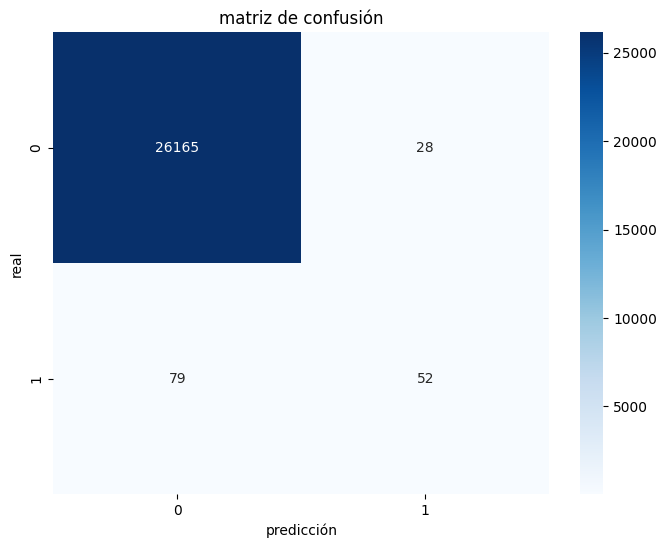

puntuación ROC-AUC: 0.9844


In [31]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Instanciamos el modelo para clasificación
# scale_pos_weight es clave si tienes pocos casos de fraude (is_fraud=1)
modelo_xgb = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 2. Entrenamos el modelo con el set de entrenamiento
modelo_xgb.fit(x_train, y_train)

# 3. Realizamos predicciones sobre el set de prueba
y_pred = modelo_xgb.predict(x_test)
y_proba = modelo_xgb.predict_proba(x_test)[:, 1]

# 4. Evaluamos el rendimiento
print("--- reporte de clasificación ---")
print(classification_report(y_test, y_pred))

# 5. Matriz de Confusión para ver aciertos y errores
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('matriz de confusión')
plt.xlabel('predicción')
plt.ylabel('real')
plt.show()

print(f"puntuación ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

In [32]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# 1. Obtenemos las probabilidades en lugar de las etiquetas fijas
y_scores = modelo_xgb_smote.predict_proba(x_test)[:, 1]

# 2. Calculamos precisión y recall para diferentes umbrales
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# 3. Encontramos el umbral que maximiza el F1-score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_threshold = thresholds[np.argmax(f1_scores)]

# 4. Aplicamos el nuevo umbral
y_pred_ajustado = (y_scores >= best_threshold).astype(int)

print(f"Mejor umbral encontrado: {best_threshold:.4f}")
print(classification_report(y_test, y_pred_ajustado))

NameError: name 'modelo_xgb_smote' is not defined

In [ ]:
from imblearn.combine import SMOTETomek
from sklearn.metrics import classification_report

# 1. Aplicamos la técnica combinada para limpiar la frontera de decisión
# Esto toma un poco más de tiempo que el SMOTE simple
smt = SMOTETomek(random_state=42)
x_train_res, y_train_res = smt.fit_resample(x_train, y_train)

# 2. Re-entrenamos el XGBoost con los datos limpios
modelo_final = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

modelo_final.fit(x_train_res, y_train_res)

# 3. Importante: Aplicamos el umbral óptimo que calculaste (0.9846) 
# o recalculamos uno nuevo para este modelo
y_probs = modelo_final.predict_proba(x_test)[:, 1]
y_pred_final = (y_probs >= 0.9846).astype(int)

print("--- Reporte con SMOTETomek y Umbral Ajustado ---")
print(classification_report(y_test, y_pred_final))

--- Reporte con SMOTETomek y Umbral Ajustado ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26193
           1       0.60      0.47      0.53       131

    accuracy                           1.00     26324
   macro avg       0.80      0.73      0.76     26324
weighted avg       1.00      1.00      1.00     26324



In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb

# 1. Olvidémonos de SMOTE por un momento. Usemos los datos reales.
# Calculamos el peso: cuántas veces es más frecuente la clase 0 que la 1
# Basado en tu media de 0.014129, la proporción es de casi 70 a 1.
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 2. Entrenamos un XGBoost optimizado para Precisión-Recall (AUPRC)
modelo_pro = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.02, # Más lento para que aprenda mejor
    max_depth=4,        # Árboles más simples para evitar sobreajuste a los pocos fraudes
    scale_pos_weight=ratio, # <--- ESTO es lo que le da importancia al fraude
    eval_metric='aucpr',    # Optimiza el área bajo la curva de Precisión-Recall
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

modelo_pro.fit(x_train, y_train)

# 3. Evaluamos con un umbral menos agresivo (empecemos en 0.5)
y_probs_pro = modelo_pro.predict_proba(x_test)[:, 1]
y_pred_pro = (y_probs_pro >= 0.5).astype(int)

print(classification_report(y_test, y_pred_pro))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98     26193
           1       0.09      0.93      0.16       131

    accuracy                           0.95     26324
   macro avg       0.54      0.94      0.57     26324
weighted avg       1.00      0.95      0.97     26324

